<a href="https://colab.research.google.com/github/GarzonDiegoFEUP/chalcogenide-perovskite-screening/blob/python311-migration/notebooks/2_1_StructureRelaxation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Install packages

In [1]:
!pip install huggingface_hub
!pip install fairchem-core

INFO: pip is looking at multiple versions of opentelemetry-sdk to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 437.7/437.7 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 73.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 450.7/450.7 kB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 303.0/303.0 kB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 126.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.0/73.0 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 887.9/887.9 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155

In [2]:
!hf auth login

A new version of huggingface_hub (1.7.1) is available! You are using version 1.6.0.
To update, run: pip install -U huggingface_hub


    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|

    To log in, `huggingface_hub` requires a token generated from https://huggingface.co/settings/tokens .
Enter your token (input will not be visible): 
Add token as git credential? [y/N]: y
Token is valid (permission: read).
The token `chalcogenide-perovskites-screening` has been saved to /roo

# Structure relaxation

In [8]:
import ase.io
import os
from ase.optimize import FIRE
from ase.filters import FrechetCellFilter
from fairchem.core import pretrained_mlip, FAIRChemCalculator

# 1. Setup the UMA model (moved outside function for efficiency)
print("Loading model...")
predictor = pretrained_mlip.get_predict_unit("uma-s-1p2", device="cuda")
calc = FAIRChemCalculator(predictor, task_name="omat")
print("Model loaded successfully!")

def relax_cif_structure(cif_filepath):
    """
    Relaxes a chalcogenide perovskite structure from a CIF file.

    Args:
        cif_filepath (str): Path to the input CIF file.

    Returns:
        tuple: (formula, initial_energy, relaxed_energy, initial_energy_per_atom, relaxed_energy_per_atom)
    """

    # 2. Load your chalcogenide perovskite from a CIF file
    atoms = ase.io.read(cif_filepath)
    atoms.calc = calc # Use the globally defined calculator

    formula = atoms.get_chemical_formula()
    initial_energy = atoms.get_potential_energy()
    num_atoms = atoms.get_global_number_of_atoms()
    initial_energy_per_atom = initial_energy / num_atoms
    print(f"Processing {cif_filepath} - Initial Energy: {initial_energy:.4f} eV, Initial Energy per Atom: {initial_energy_per_atom:.4f} eV/atom")

    # 3. Setup the relaxation filter
    # FrechetCellFilter allows both atom positions and cell tensors to relax
    filtered_atoms = FrechetCellFilter(atoms)

    # 4. Run the optimizer
    # 0.05 is the force convergence (eV/A), 100 is the max steps
    opt = FIRE(filtered_atoms)
    opt.run(fmax=0.05, steps=100)

    # 5. Save the relaxed chalcogenide perovskite
    base_name = os.path.basename(cif_filepath)
    output_filename = f"relaxed_{base_name}"
    ase.io.write(output_filename, atoms)

    relaxed_energy = atoms.get_potential_energy()
    relaxed_energy_per_atom = relaxed_energy / num_atoms
    print(f"Final Energy for {base_name}: {relaxed_energy:.4f} eV, Final Energy per Atom: {relaxed_energy_per_atom:.4f} eV/atom")
    print(f"Structure saved to {output_filename}")

    return formula, initial_energy, relaxed_energy, initial_energy_per_atom, relaxed_energy_per_atom

Loading model...
Model loaded successfully!


In [7]:
import pandas as pd
import glob

cif_directory = "data/cif_files"
cif_files = glob.glob(os.path.join(cif_directory, "*.cif"))

results = []

print("\n--- Starting batch relaxation for all CIF files ---")
for cif_filepath in cif_files:
    try:
        file_name = os.path.basename(cif_filepath)
        formula, initial_e, relaxed_e, initial_e_pa, relaxed_e_pa = relax_cif_structure(cif_filepath)
        results.append({
            "File Name": file_name,
            "Compound": formula,
            "Initial Energy (eV)": initial_e,
            "Relaxed Energy (eV)": relaxed_e,
            "Initial Energy/Atom (eV/atom)": initial_e_pa,
            "Relaxed Energy/Atom (eV/atom)": relaxed_e_pa
        })
    except Exception as e:
        print(f"Error processing {cif_filepath}: {e}")

# Create DataFrame
df_results = pd.DataFrame(results)

print("\n--- Relaxation Summary --- ")
print(df_results.head())



--- Starting batch relaxation for all CIF files ---
Processing data/cif_files/UInSe3_1.cif - Initial Energy: -110.5675 eV, Initial Energy per Atom: -5.5284 eV/atom
      Step     Time          Energy          fmax
FIRE:    0 19:43:00     -110.567511        0.779929
FIRE:    1 19:43:00     -110.610137        0.755559
FIRE:    2 19:43:00     -110.687027        0.709672
FIRE:    3 19:43:01     -110.784017        0.647002
FIRE:    4 19:43:02     -110.885181        0.573110
FIRE:    5 19:43:02     -110.976754        0.494075
FIRE:    6 19:43:03     -111.049766        0.416100
FIRE:    7 19:43:03     -111.101171        0.343469
FIRE:    8 19:43:03     -111.134731        0.271345
FIRE:    9 19:43:03     -111.148596        0.200927
FIRE:   10 19:43:04     -111.149627        0.200780
FIRE:   11 19:43:04     -111.151611        0.200513
FIRE:   12 19:43:04     -111.154481        0.200114
FIRE:   13 19:43:04     -111.158068        0.199627
FIRE:   14 19:43:04     -111.162257        0.199101
FIRE:

In [11]:
df_results['Energy Reduction/Atom (eV/atom)'] = df_results['Initial Energy/Atom (eV/atom)'] - df_results['Relaxed Energy/Atom (eV/atom)']
df_results

,File Name,Compound,Initial Energy (eV),Relaxed Energy (eV),Initial Energy/Atom (eV/atom),Relaxed Energy/Atom (eV/atom),Energy Reduction/Atom (eV/atom)
0,UInSe3_1.cif,In4Se12U4,-110.567511,-111.355339,-5.528376,-5.567767,0.039391
1,EuScS3_1.cif,Eu4S12Sc4,-151.041614,-151.553795,-7.552081,-7.577690,0.025609
2,YbEuS3_1.cif,Eu4S12Yb4,-131.165668,-145.598024,-6.558283,-7.279901,0.721618
3,SmLuS3_1.cif,Lu4S12Sm4,-127.114688,-127.180995,-6.355734,-6.359050,0.003315
4,ScUS3_1.cif,S12Sc4U4,-150.908007,-151.554284,-7.545400,-7.577714,0.032314
5,DyInS3_1.cif,Dy4In4S12,-100.182865,-101.794102,-5.009143,-5.089705,0.080562
6,UInS3_1.cif,In4S12U4,-120.609985,-122.989753,-6.030499,-6.149488,0.118988
7,CeUSe3_1.cif,Ce4Se12U4,-134.952785,-137.087559,-6.747639,-6.854378,0.106739
8,CaCeS3_1.cif,Ca4Ce4S12,-115.988670,-116.914121,-5.799433,-5.845706,0.046273
9,AlSnSe3_1.cif,Al4Se12Sn4,-79.364252,-81.673081,-3.968213,-4.083654,0.115441


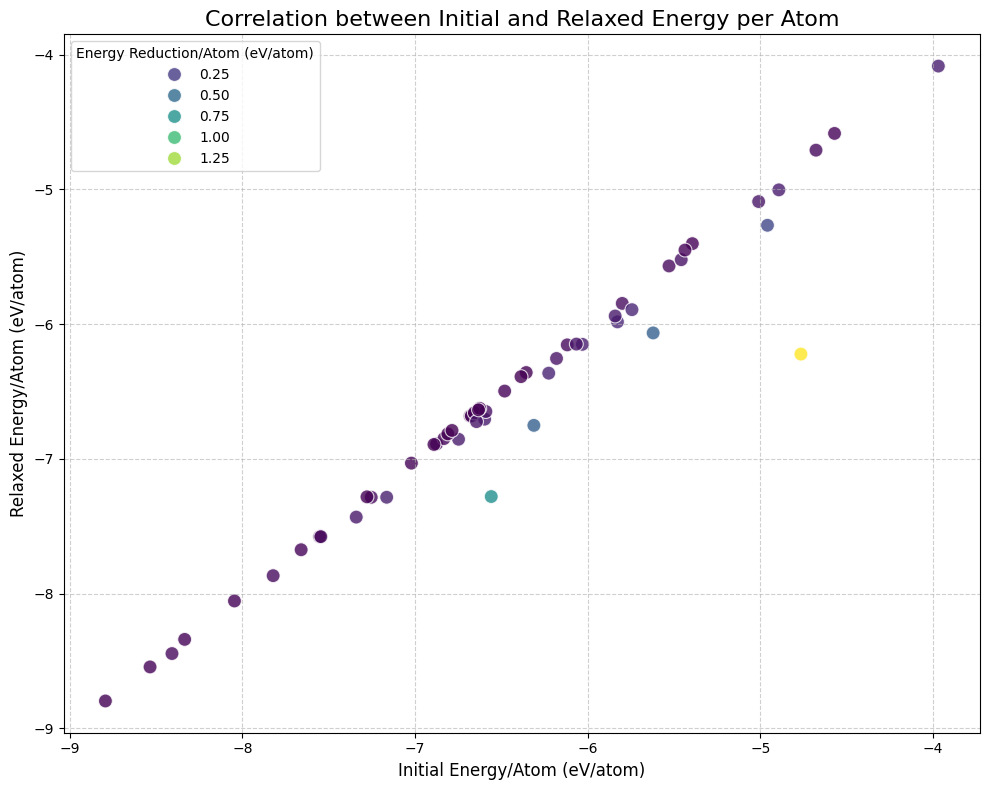

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_results,
    x='Initial Energy/Atom (eV/atom)',
    y='Relaxed Energy/Atom (eV/atom)',
    hue='Energy Reduction/Atom (eV/atom)',
    palette='viridis',  # Choose a color palette
    s=100,              # Adjust marker size
    alpha=0.8           # Adjust transparency
)
plt.title('Correlation between Initial and Relaxed Energy per Atom', fontsize=16)
plt.xlabel('Initial Energy/Atom (eV/atom)', fontsize=12)
plt.ylabel('Relaxed Energy/Atom (eV/atom)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.savefig('scatter_plot.png')

plt.show()